# Network Intrusion Detection - Data Analysis (NF-CICIDS2018-v3)

In [1]:
import os
import sys

if 'MPLBACKEND' in os.environ:
    del os.environ['MPLBACKEND']

import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import warnings
import joblib
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

# Load feature descriptions

In [3]:
dataset_path = '../data/NF-CICIDS2018-v3.csv'
features_path = '../data/NetFlow_v3_Features.csv'

features_desc = pd.read_csv(features_path)
print("NetFlow Feature Descriptions:")
print(features_desc.to_string(index=False))

NetFlow Feature Descriptions:
                           Feature                                          Description
                     IPV4_SRC_ADDR                                  IPv4 source address
                     IPV4_DST_ADDR                             IPv4 destination address
                       L4_SRC_PORT                              IPv4 source port number
                       L4_DST_PORT                         IPv4 destination port number
                          PROTOCOL                          IP protocol identifier byte
                          L7_PROTO                           Layer 7 protocol (numeric)
                          IN_BYTES                             Incoming number of bytes
                         OUT_BYTES                             Outgoing number of bytes
                           IN_PKTS                           Incoming number of packets
                          OUT_PKTS                           Outgoing number of packets
  

In [ ]:
print("Loading dataset...")
df_full = pd.read_csv(dataset_path)
print(f"Loaded: {df_full.shape[0]:,} rows with {df_full.shape[1]} columns")

Loading dataset...
Loaded: 20,115,529 rows × 55 columns


# Create stratified sample

In [5]:
target_sample_size = 100000
original_dataset_size = len(df_full)
sample_size = min(target_sample_size, original_dataset_size)

print(f"Creating stratified sample of {sample_size:,} rows...")

if sample_size < original_dataset_size and 'Attack' in df_full.columns:
    df, _ = train_test_split(df_full, train_size=sample_size, stratify=df_full['Attack'], random_state=42)
    df = df.reset_index(drop=True)
else:
    df = df_full.copy()

print(f"Sample shape: {df.shape}")
print(f"Features: {df.shape[1] - 2} (excluding Label and Attack)")

Creating stratified sample of 100,000 rows...
Sample shape: (100000, 55)
Features: 53 (excluding Label and Attack)


# Filter attacks with >500 instances

In [6]:
print("Filtering attack types with >500 instances...")
attack_counts = df['Attack'].value_counts()
print(f"\nAttack distribution before filtering:")
print(attack_counts)

attacks_to_keep = attack_counts[attack_counts > 500].index.tolist()
df = df[df['Attack'].isin(attacks_to_keep)].reset_index(drop=True)

print(f"\nAfter filtering: {len(df):,} rows, {df['Attack'].nunique()} attack types")
print(f"Kept: {attacks_to_keep}")

Filtering attack types with >500 instances...

Attack distribution before filtering:
Attack
Benign                      87070
DDOS_attack-HOIC             5132
FTP-BruteForce               1922
DDoS_attacks-LOIC-HTTP       1435
Bot                          1033
SSH-Bruteforce                937
Infilteration                 935
DoS_attacks-SlowHTTPTest      525
DoS_attacks-Hulk              498
DoS_attacks-GoldenEye         305
DoS_attacks-Slowloris         179
DDOS_attack-LOIC-UDP           17
Brute_Force_-Web                8
Brute_Force_-XSS                2
SQL_Injection                   2
Name: count, dtype: int64

After filtering: 98,989 rows, 8 attack types
Kept: ['Benign', 'DDOS_attack-HOIC', 'FTP-BruteForce', 'DDoS_attacks-LOIC-HTTP', 'Bot', 'SSH-Bruteforce', 'Infilteration', 'DoS_attacks-SlowHTTPTest']


In [7]:
print("First 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

First 5 rows:


,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,...,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack
0,1518612761345,1518612851865,172.31.66.100,49751,23.36.34.36,443,6,91,1149,14,...,0,10112,6960,4620,0,10144,4308,4966,0,Benign
1,1519224239658,1519224239677,172.31.65.68,50289,172.31.0.2,53,17,5,61,1,...,0,0,0,0,0,0,0,0,0,Benign
2,1519824878700,1519824882805,193.111.198.69,47854,172.31.66.73,3389,6,88,1912,13,...,32,1248,341,348,81,1068,585,366,0,Benign
3,1519395668212,1519395668213,172.31.67.52,55257,172.31.0.2,53,17,5,61,1,...,0,0,0,0,0,0,0,0,0,Benign
4,1518785754319,1518785754470,8.20.181.104,62183,172.31.64.111,445,6,41,132,3,...,0,151,75,75,0,151,75,75,0,Benign



Column names:
['FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS', 'IPV4_SRC_ADDR', 'L4_SRC_PORT', 'IPV4_DST_ADDR', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT', 'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN', 'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES', 'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS', 'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS', 'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT', 'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES', 'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES', 'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT', 'ICMP_TYPE', 'ICMP_IPV4_TYPE', 'DNS_QUERY_ID', 'DNS_QUERY_TYPE', 'DNS_TTL_ANSWER', 'FTP_COMMAND_RET_CODE', 'SRC_TO_DST_IAT_MIN', 'SRC_TO_DST_IAT_MAX', 'SRC_TO_DST_IAT_AVG', 'SRC_TO_DS

In [8]:
print("Dataset information:")
df.info()

print("\nData types summary:")
print(df.dtypes.value_counts())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98989 entries, 0 to 98988
Data columns (total 55 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   FLOW_START_MILLISECONDS      98989 non-null  int64 
 1   FLOW_END_MILLISECONDS        98989 non-null  int64 
 2   IPV4_SRC_ADDR                98989 non-null  object
 3   L4_SRC_PORT                  98989 non-null  int64 
 4   IPV4_DST_ADDR                98989 non-null  object
 5   L4_DST_PORT                  98989 non-null  int64 
 6   PROTOCOL                     98989 non-null  int64 
 7   L7_PROTO                     98989 non-null  int64 
 8   IN_BYTES                     98989 non-null  int64 
 9   IN_PKTS                      98989 non-null  int64 
 10  OUT_BYTES                    98989 non-null  int64 
 11  OUT_PKTS                     98989 non-null  int64 
 12  TCP_FLAGS                    98989 non-null  int64 
 13  CLIENT_TCP

# Check missing values

In [9]:
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing_values, 'Percentage': missing_percent}).sort_values(by='Missing_Count', ascending=False)

if missing_df['Missing_Count'].sum() > 0:
    print("Columns with missing values:")
    print(missing_df[missing_df['Missing_Count'] > 0])
else:
    print("No missing values detected")

No missing values detected


# Class distribution

In [10]:
print("Binary Label Distribution (0=Benign, 1=Attack):")
label_counts = df['Label'].value_counts().sort_index()
for label, count in label_counts.items():
    label_name = "Attack" if label == 1 else "Benign"
    percentage = (count / len(df)) * 100
    print(f"  {label} ({label_name}): {count:,} ({percentage:.2f}%)")

print("\nAttack Type Distribution:")
attack_dist = df['Attack'].value_counts()
for attack_type, count in attack_dist.items():
    percentage = (count / len(df)) * 100
    print(f"  {attack_type}: {count:,} ({percentage:.2f}%)")

Binary Label Distribution (0=Benign, 1=Attack):
  0 (Benign): 87,070 (87.96%)
  1 (Attack): 11,919 (12.04%)

Attack Type Distribution:
  Benign: 87,070 (87.96%)
  DDOS_attack-HOIC: 5,132 (5.18%)
  FTP-BruteForce: 1,922 (1.94%)
  DDoS_attacks-LOIC-HTTP: 1,435 (1.45%)
  Bot: 1,033 (1.04%)
  SSH-Bruteforce: 937 (0.95%)
  Infilteration: 935 (0.94%)
  DoS_attacks-SlowHTTPTest: 525 (0.53%)


# Visualize class distribution

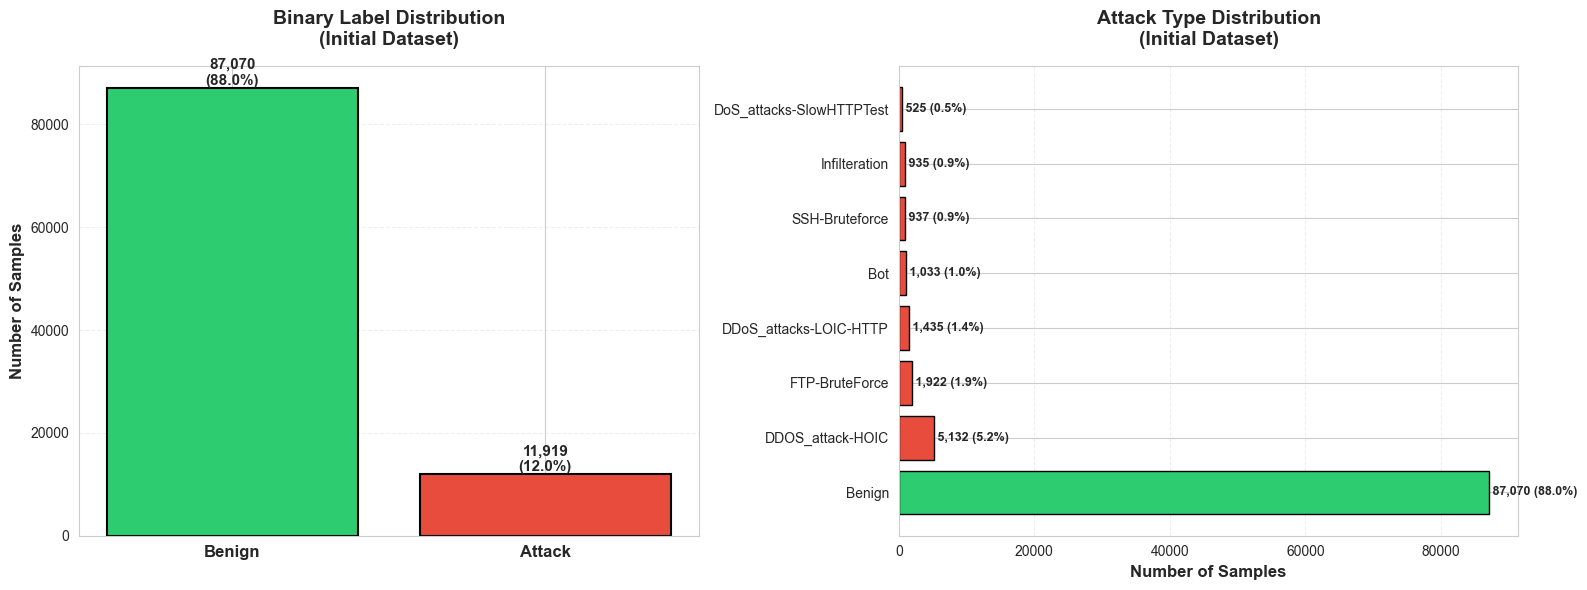

Imbalance ratio: 7.31:1


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

label_counts = df['Label'].value_counts().sort_index()
colors = ['#2ecc71', '#e74c3c']
labels = ['Benign', 'Attack']
bars = axes[0].bar(range(len(label_counts)), label_counts.values, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_xticks(range(len(label_counts)))
axes[0].set_xticklabels(labels, fontsize=12, fontweight='bold')
axes[0].set_title('Binary Label Distribution\n(Initial Dataset)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

for bar, count in zip(bars, label_counts.values):
    percentage = (count / len(df)) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'{count:,}\n({percentage:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

attack_counts = df['Attack'].value_counts()
colors_attack = ['#2ecc71' if att == 'Benign' else '#e74c3c' for att in attack_counts.index]
axes[1].barh(attack_counts.index, attack_counts.values, color=colors_attack, edgecolor='black', linewidth=1)
axes[1].set_title('Attack Type Distribution\n(Initial Dataset)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Number of Samples', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3, linestyle='--')

for i, (attack_type, count) in enumerate(attack_counts.items()):
    percentage = (count / len(df)) * 100
    axes[1].text(count, i, f' {count:,} ({percentage:.1f}%)', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Imbalance ratio: {label_counts.max()/label_counts.min():.2f}:1")

# Identify data leakage features

In [12]:
leakage_features = [
    'FLOW_END_MILLISECONDS',
    'FLOW_DURATION_MILLISECONDS',
    'DURATION_IN',
    'DURATION_OUT',
    'SRC_TO_DST_IAT_MIN',
    'SRC_TO_DST_IAT_MAX',
    'SRC_TO_DST_IAT_AVG',
    'SRC_TO_DST_IAT_STDDEV',
    'DST_TO_SRC_IAT_MIN',
    'DST_TO_SRC_IAT_MAX',
    'DST_TO_SRC_IAT_AVG',
    'DST_TO_SRC_IAT_STDDEV'
]

leakage_features = [f for f in leakage_features if f in df.columns]
print(f"Data leakage features ({len(leakage_features)} total):")
for feature in leakage_features:
    print(f"  - {feature}")

Data leakage features (12 total):
  - FLOW_END_MILLISECONDS
  - FLOW_DURATION_MILLISECONDS
  - DURATION_IN
  - DURATION_OUT
  - SRC_TO_DST_IAT_MIN
  - SRC_TO_DST_IAT_MAX
  - SRC_TO_DST_IAT_AVG
  - SRC_TO_DST_IAT_STDDEV
  - DST_TO_SRC_IAT_MIN
  - DST_TO_SRC_IAT_MAX
  - DST_TO_SRC_IAT_AVG
  - DST_TO_SRC_IAT_STDDEV


# Analyze class distribution before balancing

In [13]:
attack_counts = df['Attack'].value_counts()
print("Class Distribution Before Balancing:")
print(attack_counts)

majority_class = attack_counts.idxmax()
majority_count = attack_counts.max()
minority_total = len(df[df['Attack'] != majority_class])
print(f"\nMajority class: '{majority_class}' ({majority_count:,} samples)")
print(f"Imbalance ratio: {majority_count/minority_total:.2f}:1")

Class Distribution Before Balancing:
Attack
Benign                      87070
DDOS_attack-HOIC             5132
FTP-BruteForce               1922
DDoS_attacks-LOIC-HTTP       1435
Bot                          1033
SSH-Bruteforce                937
Infilteration                 935
DoS_attacks-SlowHTTPTest      525
Name: count, dtype: int64

Majority class: 'Benign' (87,070 samples)
Imbalance ratio: 7.31:1


# Oversample attacks to 60/40 ratio

In [14]:
benign_count = len(df[df['Attack'] == 'Benign'])
attack_count = len(df[df['Attack'] != 'Benign'])

print("Rebalancing Strategy (OVERSAMPLING):")
print(f"Original: Benign={benign_count:,}, Attacks={attack_count:,}")
print(f"Original ratio: {benign_count/(benign_count+attack_count)*100:.1f}% / {attack_count/(benign_count+attack_count)*100:.1f}%")

target_attack_size = int(benign_count * (40/60))

df_benign = df[df['Attack'] == 'Benign']
df_attacks_original = df[df['Attack'] != 'Benign']
df_attacks = df_attacks_original.sample(n=target_attack_size, replace=True, random_state=42)

df_balanced = pd.concat([df_benign, df_attacks]).sample(frac=1, random_state=42).reset_index(drop=True)

benign_final = len(df_benign)
attack_final = len(df_attacks)
total_final = len(df_balanced)

print(f"\nBalanced: {total_final:,} samples")
print(f"  Benign: {benign_final:,} ({benign_final/total_final*100:.1f}%)")
print(f"  Attacks: {attack_final:,} ({attack_final/total_final*100:.1f}%)")
print(f"  Oversampled {attack_final - attack_count:,} attack samples")

Rebalancing Strategy (OVERSAMPLING):
Original: Benign=87,070, Attacks=11,919
Original ratio: 88.0% / 12.0%

Balanced: 145,116 samples
  Benign: 87,070 (60.0%)
  Attacks: 58,046 (40.0%)
  Oversampled 46,127 attack samples


# Visualize balanced distribution

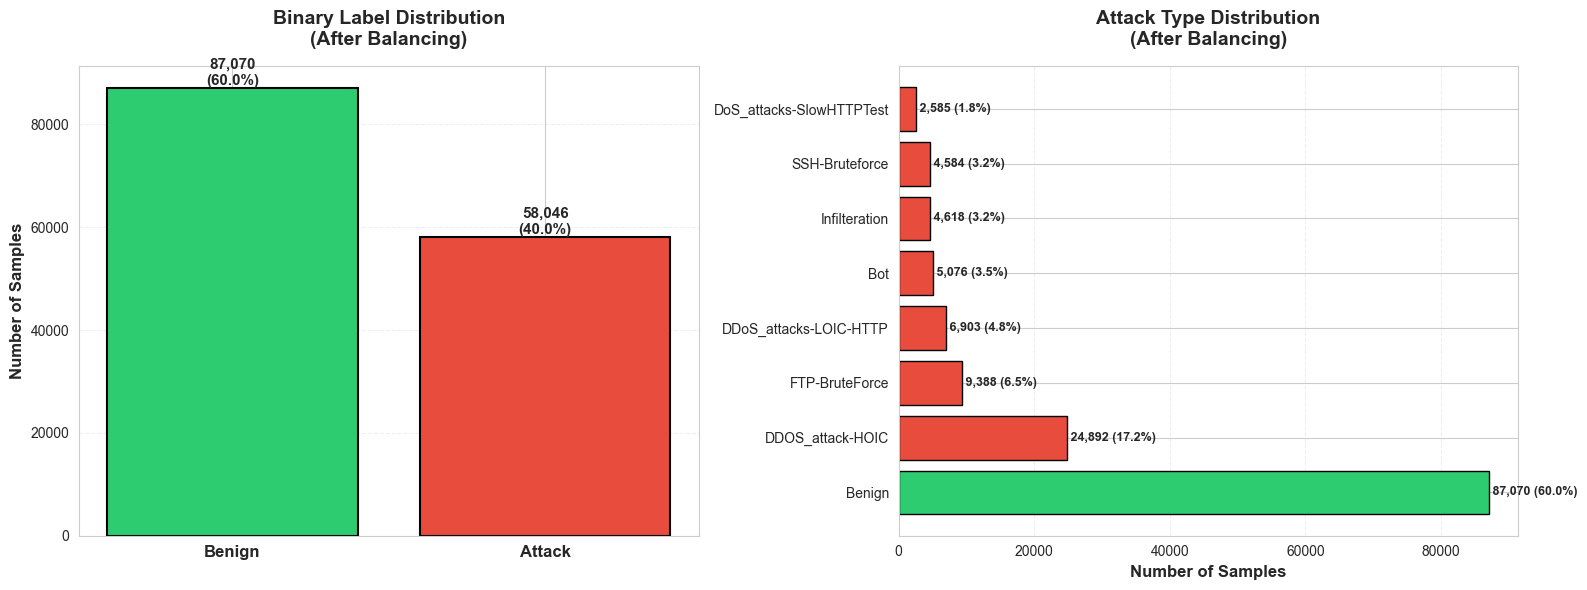

Improved balance ratio: 1.50:1


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

label_counts_balanced = df_balanced['Label'].value_counts().sort_index()
colors = ['#2ecc71', '#e74c3c']
labels = ['Benign', 'Attack']
bars = axes[0].bar(range(len(label_counts_balanced)), label_counts_balanced.values, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_xticks(range(len(label_counts_balanced)))
axes[0].set_xticklabels(labels, fontsize=12, fontweight='bold')
axes[0].set_title('Binary Label Distribution\n(After Balancing)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

for bar, count in zip(bars, label_counts_balanced.values):
    percentage = (count / len(df_balanced)) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'{count:,}\n({percentage:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

attack_counts_balanced = df_balanced['Attack'].value_counts()
colors_attack = ['#2ecc71' if att == 'Benign' else '#e74c3c' for att in attack_counts_balanced.index]
axes[1].barh(attack_counts_balanced.index, attack_counts_balanced.values, color=colors_attack, edgecolor='black', linewidth=1)
axes[1].set_title('Attack Type Distribution\n(After Balancing)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Number of Samples', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3, linestyle='--')

for i, (attack_type, count) in enumerate(attack_counts_balanced.items()):
    percentage = (count / len(df_balanced)) * 100
    axes[1].text(count, i, f' {count:,} ({percentage:.1f}%)', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Improved balance ratio: {label_counts_balanced.max()/label_counts_balanced.min():.2f}:1")

# Remove leakage features and non-predictive columns

In [16]:
columns_to_drop = ['FLOW_START_MILLISECONDS'] + leakage_features
columns_to_drop = [col for col in columns_to_drop if col in df_balanced.columns]

print(f"Dropping {len(columns_to_drop)} columns:")
for col in columns_to_drop:
    print(f"  - {col}")

df_model = df_balanced.drop(columns=columns_to_drop, errors='ignore')

print(f"\nDataset after removal: {df_model.shape}")
print(f"Features: {df_model.shape[1] - 1} (excluding Label)")

Dropping 13 columns:
  - FLOW_START_MILLISECONDS
  - FLOW_END_MILLISECONDS
  - FLOW_DURATION_MILLISECONDS
  - DURATION_IN
  - DURATION_OUT
  - SRC_TO_DST_IAT_MIN
  - SRC_TO_DST_IAT_MAX
  - SRC_TO_DST_IAT_AVG
  - SRC_TO_DST_IAT_STDDEV
  - DST_TO_SRC_IAT_MIN
  - DST_TO_SRC_IAT_MAX
  - DST_TO_SRC_IAT_AVG
  - DST_TO_SRC_IAT_STDDEV

Dataset after removal: (145116, 42)
Features: 41 (excluding Label)


# Train/test split

In [17]:
train_size = 0.10
print(f"Train/Test Split: {train_size*100:.0f}% training, {(1-train_size)*100:.0f}% test")

train_raw, test_raw = train_test_split(df_model, train_size=train_size, random_state=42, stratify=df_model['Label'])

print(f"\nTraining: {train_raw.shape[0]:,} samples")
print(f"Test: {test_raw.shape[0]:,} samples")

print("\nTraining distribution:")
for label, count in train_raw['Label'].value_counts().sort_index().items():
    print(f"  {label}: {count:,} ({count/len(train_raw)*100:.1f}%)")

print("\nTest distribution:")
for label, count in test_raw['Label'].value_counts().sort_index().items():
    print(f"  {label}: {count:,} ({count/len(test_raw)*100:.1f}%)")

Train/Test Split: 10% training, 90% test

Training: 14,511 samples
Test: 130,605 samples

Training distribution:
  0: 8,707 (60.0%)
  1: 5,804 (40.0%)

Test distribution:
  0: 78,363 (60.0%)
  1: 52,242 (40.0%)


# Identify feature types

In [18]:
categorical_cols = ['IPV4_SRC_ADDR', 'IPV4_DST_ADDR', 'PROTOCOL', 'L7_PROTO']
categorical_cols = [col for col in categorical_cols if col in train_raw.columns]
numerical_cols = [col for col in train_raw.columns if col not in categorical_cols and col not in ['Label', 'Attack']]

print(f"Categorical features ({len(categorical_cols)}):")
for col in categorical_cols:
    print(f"  - {col} ({train_raw[col].nunique():,} unique values)")

print(f"\nNumerical features ({len(numerical_cols)}):")
print(f"  {', '.join(numerical_cols[:10])}...")
if len(numerical_cols) > 10:
    print(f"  ... and {len(numerical_cols) - 10} more")

Categorical features (4):
  - IPV4_SRC_ADDR (1,546 unique values)
  - IPV4_DST_ADDR (1,366 unique values)
  - PROTOCOL (5 unique values)
  - L7_PROTO (44 unique values)

Numerical features (36):
  L4_SRC_PORT, L4_DST_PORT, IN_BYTES, IN_PKTS, OUT_BYTES, OUT_PKTS, TCP_FLAGS, CLIENT_TCP_FLAGS, SERVER_TCP_FLAGS, MIN_TTL...
  ... and 26 more


# Check missing values

In [19]:
missing_train = train_raw[numerical_cols].isnull().sum()
missing_test = test_raw[numerical_cols].isnull().sum()

if missing_train.sum() == 0 and missing_test.sum() == 0:
    print("No missing values in numerical features")
else:
    print("Missing values found:")
    if missing_train.sum() > 0:
        print("Training:", missing_train[missing_train > 0])
    if missing_test.sum() > 0:
        print("Test:", missing_test[missing_test > 0])

No missing values in numerical features


# Impute missing values

In [20]:
print("Imputing missing values...")
imputer = SimpleImputer(strategy='median')

train_num = pd.DataFrame(imputer.fit_transform(train_raw[numerical_cols]), columns=numerical_cols, index=train_raw.index)
test_num = pd.DataFrame(imputer.transform(test_raw[numerical_cols]), columns=numerical_cols, index=test_raw.index)

print(f"Training: {train_num.isnull().sum().sum()} missing")
print(f"Test: {test_num.isnull().sum().sum()} missing")

Imputing missing values...
Training: 0 missing
Test: 0 missing


# Standardize numerical features

In [21]:
print("Standardizing numerical features...")
scaler = StandardScaler()

train_num_scaled = pd.DataFrame(scaler.fit_transform(train_num), columns=numerical_cols, index=train_raw.index)
test_num_scaled = pd.DataFrame(scaler.transform(test_num), columns=numerical_cols, index=test_raw.index)

print("\nSample statistics (training, first 5 features):")
print(train_num_scaled[numerical_cols[:5]].describe().round(3))

Standardizing numerical features...

Sample statistics (training, first 5 features):
       L4_SRC_PORT  L4_DST_PORT   IN_BYTES    IN_PKTS  OUT_BYTES
count    14511.000    14511.000  14511.000  14511.000  14511.000
mean        -0.000       -0.000     -0.000      0.000     -0.000
std          1.000        1.000      1.000      1.000      1.000
min         -3.889       -0.281     -0.019     -0.013     -0.027
25%         -0.089       -0.273     -0.018     -0.013     -0.026
50%          0.168       -0.270     -0.015     -0.009     -0.024
75%          0.568       -0.220     -0.010     -0.009     -0.019
max          1.053        8.626    120.404    120.429     91.262


# Encode categorical features

In [22]:
print("Encoding categorical features...")
train_cat_encoded = train_raw[categorical_cols].copy()
test_cat_encoded = test_raw[categorical_cols].copy()
encoders = {}

for col in categorical_cols:
    encoder = LabelEncoder()
    train_cat_encoded[col] = encoder.fit_transform(train_raw[col].astype(str))

    test_values = test_raw[col].astype(str)
    test_cat_encoded[col] = test_values.apply(lambda x: encoder.transform([x])[0] if x in encoder.classes_ else -1)

    encoders[col] = encoder
    n_test_unseen = (test_cat_encoded[col] == -1).sum()
    print(f"  {col}: {len(encoder.classes_):,} categories" + (f", {n_test_unseen:,} unseen in test" if n_test_unseen > 0 else ""))

Encoding categorical features...
  IPV4_SRC_ADDR: 1,546 categories, 8,228 unseen in test
  IPV4_DST_ADDR: 1,366 categories, 6,038 unseen in test
  PROTOCOL: 5 categories
  L7_PROTO: 44 categories, 138 unseen in test


# Remove low-variance features

In [23]:
train_features = pd.concat([train_num_scaled, train_cat_encoded], axis=1)
test_features = pd.concat([test_num_scaled, test_cat_encoded], axis=1)

print("Removing low-variance features...")
low_variance_cols = [col for col in train_features.columns if train_features[col].nunique() <= 1]

if low_variance_cols:
    print(f"Found {len(low_variance_cols)} low-variance features:")
    for col in low_variance_cols:
        print(f"  - {col}")
    train_features = train_features.drop(columns=low_variance_cols)
    test_features = test_features.drop(columns=low_variance_cols, errors='ignore')
else:
    print("No low-variance features detected")

print(f"\nFinal feature count: {train_features.shape[1]}")

Removing low-variance features...
Found 1 low-variance features:
  - FTP_COMMAND_RET_CODE

Final feature count: 39


# Create final datasets

## Save test_raw dataset (BEFORE processing)

In [24]:
output_dir = '../data/processed'

test_raw_path = os.path.join(output_dir, 'test_raw.csv')
test_raw.to_csv(test_raw_path, index=False)

print(f"Test Raw: ({test_raw.shape[0]:,}, {test_raw.shape[1]})")

Test Raw: (130,605, 42)


# Save preprocessing artifacts

In [27]:
artifacts_dir = '../data/preprocessing_artifacts'
os.makedirs(artifacts_dir, exist_ok=True)

joblib.dump(scaler, os.path.join(artifacts_dir, 'scaler.pkl'))
print("Scaler saved")

joblib.dump(imputer, os.path.join(artifacts_dir, 'imputer.pkl'))
print("Imputer saved")

joblib.dump(encoders, os.path.join(artifacts_dir, 'encoders.pkl'))
print(f"Encoders saved ({len(encoders)} encoders)")

feature_config = {
    'numerical_cols': numerical_cols,
    'categorical_cols': categorical_cols,
    'final_features': list(train_features.columns), 
    'leakage_features': leakage_features,
    'low_variance_features': low_variance_cols if low_variance_cols else []
}
joblib.dump(feature_config, os.path.join(artifacts_dir, 'feature_config.pkl'))
print("✓ Feature configuration saved")

print(f"\nAll preprocessing artifacts saved to: {artifacts_dir}")
print(f"  - scaler.pkl")
print(f"  - imputer.pkl")
print(f"  - encoders.pkl")
print(f"  - feature_config.pkl")
print(f"\nThese artifacts will be used by FeaturePreprocessor for real-time preprocessing")

Scaler saved
Imputer saved
Encoders saved (4 encoders)
✓ Feature configuration saved

All preprocessing artifacts saved to: ../data/preprocessing_artifacts
  - scaler.pkl
  - imputer.pkl
  - encoders.pkl
  - feature_config.pkl

These artifacts will be used by FeaturePreprocessor for real-time preprocessing


# Save processed datasets (train and eval only)

In [28]:
os.makedirs(output_dir, exist_ok=True)

train_df = train_features.copy()
train_df['Label'] = train_raw['Label'].values
train_df['Attack'] = train_raw['Attack'].values

test_df = test_features.copy()
test_df['Label'] = test_raw['Label'].values
test_df['Attack'] = test_raw['Attack'].values

eval_size = int(0.2 * len(test_df))
eval_df, test_df = train_test_split(test_df, train_size=eval_size, random_state=42, stratify=test_df['Label'])

train_df.to_csv(os.path.join(output_dir, 'train_data.csv'), index=False)
test_df.to_csv(os.path.join(output_dir, 'test_data.csv'), index=False)
eval_df.to_csv(os.path.join(output_dir, 'eval_data.csv'), index=False)

print(f"Training: ({train_df.shape[0]:,}, {train_df.shape[1]})")
print(f"Test: ({test_df.shape[0]:,}, {test_df.shape[1]})")
print(f"Evaluation: {eval_df.shape[0]:,}, {eval_df.shape[1]}")

Training: (14,511, 41)
Test: (104,484, 41)
Evaluation: 26,121, 41


# Correlation analysis

Top 20 features correlated with Label:
  TCP_WIN_MAX_IN                           0.6213
  IPV4_DST_ADDR                            0.4719
  TCP_FLAGS                                0.4272
  PROTOCOL                                 0.4270
  CLIENT_TCP_FLAGS                         0.4013
  DNS_TTL_ANSWER                           0.3729
  DNS_QUERY_ID                             0.3457
  IPV4_SRC_ADDR                            0.2581
  SHORTEST_FLOW_PKT                        0.2270
  L7_PROTO                                 0.2124
  MAX_IP_PKT_LEN                           0.2033
  LONGEST_FLOW_PKT                         0.2033
  SRC_TO_DST_SECOND_BYTES                  0.1855
  MIN_TTL                                  0.1842
  DST_TO_SRC_SECOND_BYTES                  0.1835
  MAX_TTL                                  0.1834
  ICMP_TYPE                                0.1652
  ICMP_IPV4_TYPE                           0.1652
  L4_SRC_PORT                              0.1601
  DNS_QUERY

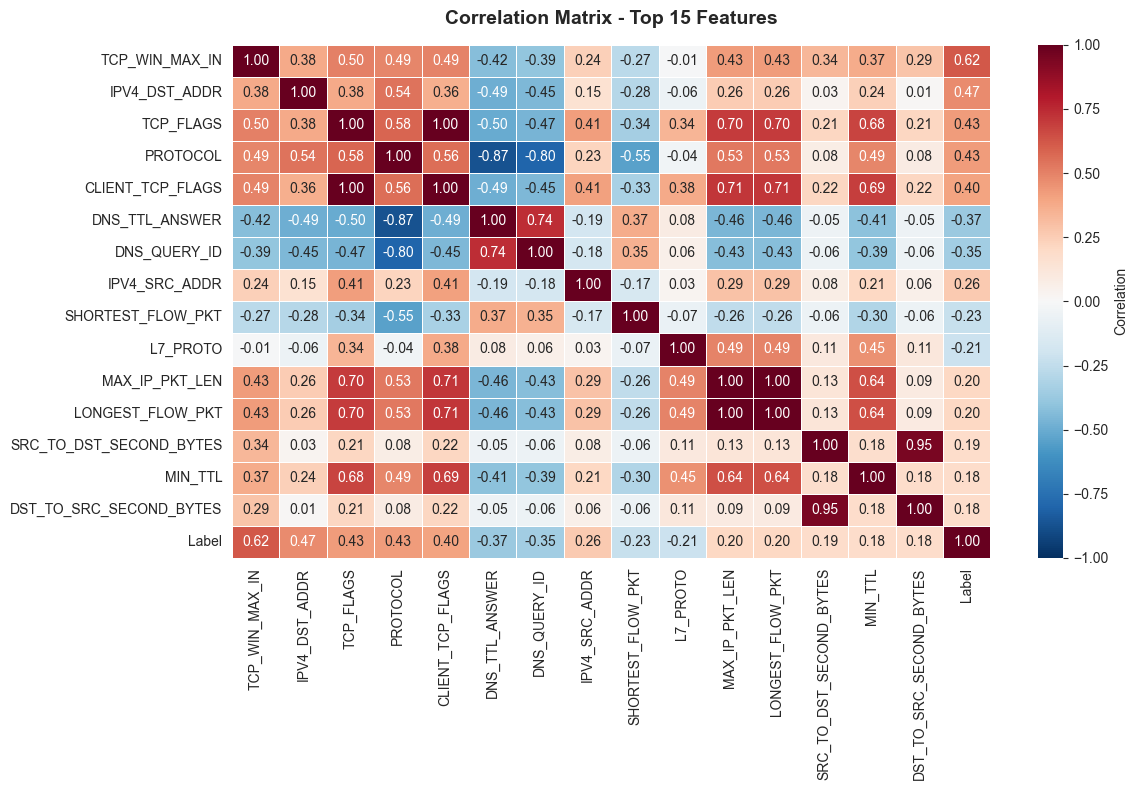

In [29]:
df_analysis = pd.concat([train_df, test_df], ignore_index=True)
df_analysis_numeric = df_analysis.drop(columns=['Attack'], errors='ignore')
correlation_with_label = df_analysis_numeric.corr()['Label'].abs().sort_values(ascending=False)

print("Top 20 features correlated with Label:")
for feature, corr in list(correlation_with_label.head(21).items())[1:]:
    print(f"  {feature:<40} {corr:.4f}")

top_n = 15
top_features = correlation_with_label.head(top_n + 1).index[1:]

plt.figure(figsize=(12, 8))
correlation_subset = df_analysis_numeric[list(top_features) + ['Label']].corr()
sns.heatmap(correlation_subset, annot=True, cmap='RdBu_r', fmt='.2f', linewidths=0.5, center=0, vmin=-1, vmax=1, cbar_kws={'label': 'Correlation'})
plt.title(f'Correlation Matrix - Top {top_n} Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Feature distributions

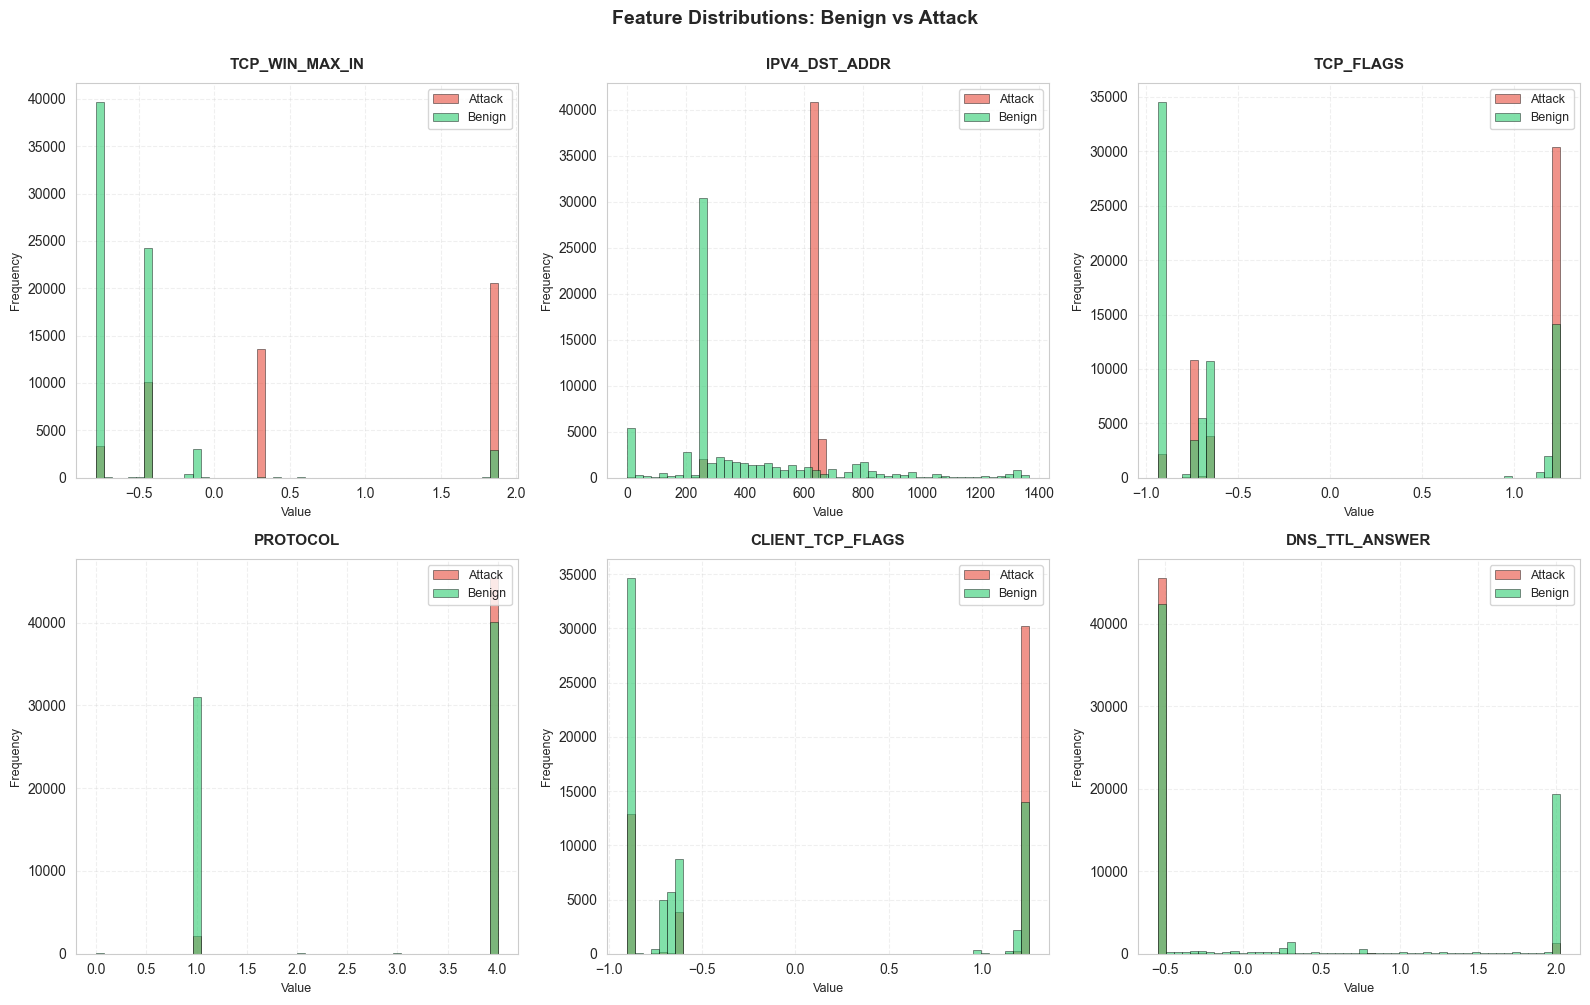

In [30]:
top_features_to_plot = correlation_with_label.head(7).index[1:7]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, feature in enumerate(top_features_to_plot):
    for label_val in df_analysis['Label'].unique():
        data = df_analysis[df_analysis['Label'] == label_val][feature]
        label_name = 'Attack' if label_val == 1 else 'Benign'
        color = '#e74c3c' if label_val == 1 else '#2ecc71'
        axes[idx].hist(data, alpha=0.6, label=label_name, bins=50, color=color, edgecolor='black', linewidth=0.5)

    axes[idx].set_title(f'{feature}', fontsize=11, fontweight='bold', pad=10)
    axes[idx].set_xlabel('Value', fontsize=9)
    axes[idx].set_ylabel('Frequency', fontsize=9)
    axes[idx].legend(loc='upper right', fontsize=9)
    axes[idx].grid(True, alpha=0.3, linestyle='--')

plt.suptitle('Feature Distributions: Benign vs Attack', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Visualize dataset split

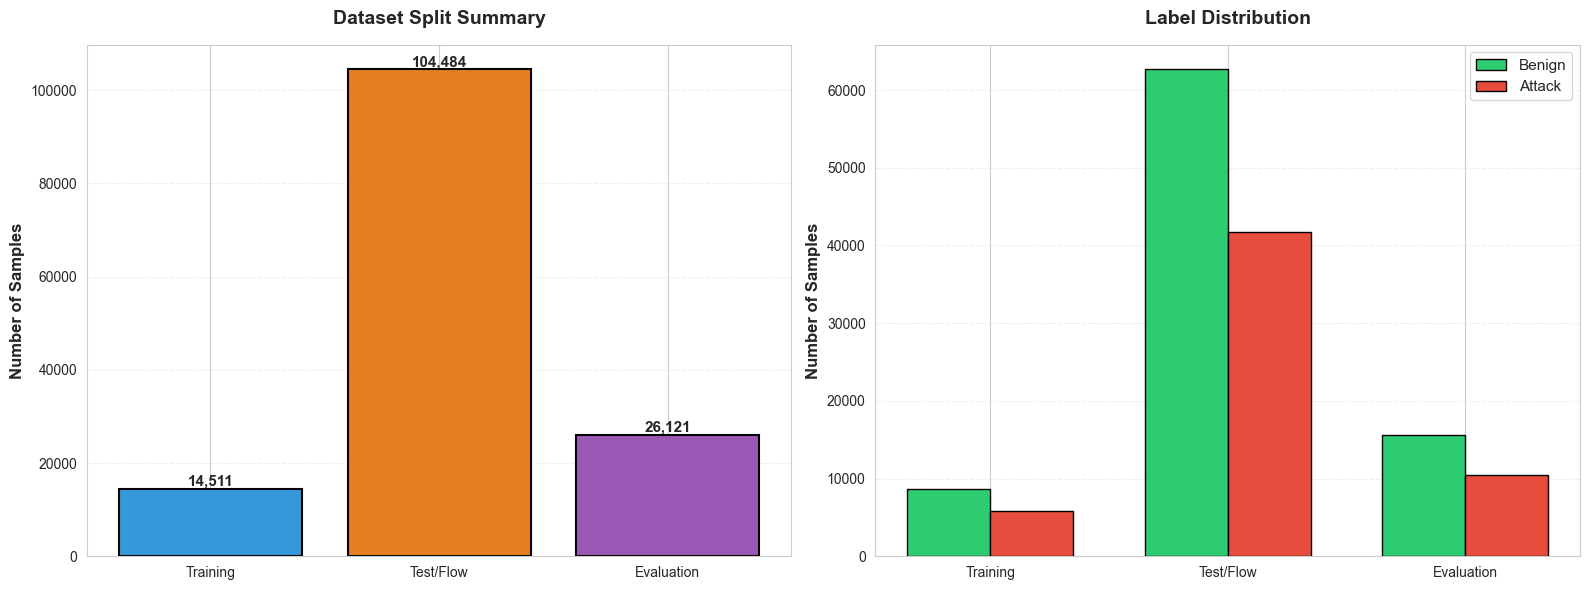

In [31]:
datasets = ['Training', 'Test/Flow', 'Evaluation']
counts = [len(train_df), len(test_df), len(eval_df)]
colors = ['#3498db', '#e67e22', '#9b59b6']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars = axes[0].bar(datasets, counts, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_title('Dataset Split Summary', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'{count:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

train_benign = (train_df['Label'] == 0).sum()
train_attack = (train_df['Label'] == 1).sum()
test_benign = (test_df['Label'] == 0).sum()
test_attack = (test_df['Label'] == 1).sum()
eval_benign = (eval_df['Label'] == 0).sum()
eval_attack = (eval_df['Label'] == 1).sum()

x = np.arange(len(datasets))
width = 0.35

axes[1].bar(x - width/2, [train_benign, test_benign, eval_benign], width, label='Benign', color='#2ecc71', edgecolor='black', linewidth=1)
axes[1].bar(x + width/2, [train_attack, test_attack, eval_attack], width, label='Attack', color='#e74c3c', edgecolor='black', linewidth=1)

axes[1].set_title('Label Distribution', fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(datasets)
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Summary

In [32]:
print("="*80)
print("DATA ANALYSIS SUMMARY")
print("="*80)

print(f"\nOriginal dataset: {original_dataset_size:,} samples")
print(f"After balancing: {len(df_balanced):,} samples")

print(f"\nFinal datasets:")
print(f"  Training: {len(train_df):,} ({len(train_df)/(len(train_df)+len(test_df)+len(eval_df))*100:.1f}%)")
print(f"    Benign={train_benign:,}, Attack={train_attack:,}")
print(f"  Test/Flow: {len(test_df):,} ({len(test_df)/(len(train_df)+len(test_df)+len(eval_df))*100:.1f}%)")
print(f"    Benign={test_benign:,}, Attack={test_attack:,}")
print(f"  Evaluation: {len(eval_df):,} ({len(eval_df)/(len(train_df)+len(test_df)+len(eval_df))*100:.1f}%)")
print(f"    Benign={eval_benign:,}, Attack={eval_attack:,}")

print(f"\nPreprocessing applied:")
print(f"  - Removed {len(leakage_features)} data leakage features")
print(f"  - Encoded {len(categorical_cols)} categorical features")
print(f"  - Standardized {len(numerical_cols)} numerical features")
print(f"  - Final: {train_df.shape[1] - 1} features")

print(f"\nTop 3 predictive features:")
for i, (feature, corr) in enumerate(list(correlation_with_label.head(4).items())[1:4], 1):
    print(f"  {i}. {feature} (r={corr:.4f})")

print("\n" + "="*80)

DATA ANALYSIS SUMMARY

Original dataset: 20,115,529 samples
After balancing: 145,116 samples

Final datasets:
  Training: 14,511 (10.0%)
    Benign=8,707, Attack=5,804
  Test/Flow: 104,484 (72.0%)
    Benign=62,690, Attack=41,794
  Evaluation: 26,121 (18.0%)
    Benign=15,673, Attack=10,448

Preprocessing applied:
  - Removed 12 data leakage features
  - Encoded 4 categorical features
  - Standardized 36 numerical features
  - Final: 40 features

Top 3 predictive features:
  1. TCP_WIN_MAX_IN (r=0.6213)
  2. IPV4_DST_ADDR (r=0.4719)
  3. TCP_FLAGS (r=0.4272)

